# Model Experiments and Testing


In this notebook, we will conduct experiments with different models to find the best one for predicting the amount claimed in insurance. 
1. We start by defining a baseline model which is one that output always the mean of the target variable. 
2. Then we will use a simple Random Forest Regressor. 
3. Next we will use a two step approach where we first train a classifier to predict whether a claim is zero or not, and then a regressor to predict the amount claimed for non-zero claims.
4. Finally, we will use Optuna to optimize the hyperparameters of a LightGBM Regressor that use the Tweedie loss function (commonly used for insurance claims data [source](https://scikit-learn.org/stable/auto_examples/linear_model/plot_tweedie_regression_insurance_claims.html#sphx-glr-auto-examples-linear-model-plot-tweedie-regression-insurance-claims-py))



In [ ]:

from policyML.bronze.bronze import get_db_connection
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# Connect to db
conn = get_db_connection()
schema = 'silver'
table_name = 'insurance'

query = f'SELECT * FROM "{schema}"."{table_name}";'
data = pd.read_sql(query, conn)
conn.close()

data.head()

/var/folders/lx/thnwywfs79x9xsl2bq8yrjy00000gn/T/ipykernel_90841/204418286.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, conn)


,id,insurance_coverage_days,insured_age,insured_sex,insured_status,insured_noclaimyears,insured_creditscore,insured_regionid,insured_drivearea,car_use,...,brake_07ms2_1000km,leftturn_low_1000km,leftturn_med_1000km,leftturn_high_1000km,rightturn_low_1000km,rightturn_med_1000km,rightturn_high_1000km,amt_claim,nb_claim,dwh_create_data
0,25859,365,48,0,0,32,865,89,1,3,...,0,10,1,0,231,44,1,0.0,0,2025-06-28 14:16:47.807163
1,10785,356,51,1,1,35,861,38,0,1,...,0,896,282,22,1173,428,39,0.0,0,2025-06-28 14:16:47.807163
2,24808,365,63,1,1,44,856,36,1,3,...,0,26,3,0,125,20,0,0.0,0,2025-06-28 14:16:47.807163
3,49535,366,37,1,0,20,686,60,0,1,...,0,7,0,0,4,0,0,0.0,0,2025-06-28 14:16:47.807163
4,3346,181,50,1,0,23,539,38,1,3,...,1,10,2,0,12,1,0,0.0,0,2025-06-28 14:16:47.807163


## 1. Baseline Model


In [ ]:
mean_claim = y_train.mean()
mean_claim_pred_train = np.full_like(y_train, mean_claim)
mean_claim_pred_test = np.full_like(y_test, mean_claim)

# rmse
mean_claim_rmse_train = mean_squared_error(y_train, mean_claim_pred_train)
mean_claim_rmse_test = mean_squared_error(y_test, mean_claim_pred_test)
print(f"Mean Claim RMSE Train: {mean_claim_rmse_train:,.2f}")
print(f"Mean Claim RMSE Test: {mean_claim_rmse_test:,.2f}")

Mean Claim RMSE Train: 4,865,505.30
Mean Claim RMSE Test: 95,960,548.35


We try to beat the RMSE of the baseline model.

## 2. Random Forest Regressor



In [ ]:
data.drop(columns=["id",'dwh_create_data'],inplace=True)

# Train test split
X = data.drop(columns="amt_claim")
y = data["amt_claim"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=42)

# Define ML model
rf = RandomForestRegressor(verbose=0,n_jobs=-1)

rf.fit(X_train,y_train)

# save y
y_real = data["amt_claim"]

data.drop(columns=["amt_claim"],inplace=True)

# Run the inference step on the data
y_pred_train = rf.predict(X_train)

y_pred_test = rf.predict(X_test)

# calculate the RMSE
from sklearn.metrics import mean_squared_error
rmse_train = mean_squared_error(y_train, y_pred_train)
rmse_test = mean_squared_error(y_test, y_pred_test)
print(f"RMSE Train: {rmse_train:,.2f}")
print(f"RMSE Test: {rmse_test:,.2f}")

RMSE Train: 405,061.50
RMSE Test: 2,471,045.63


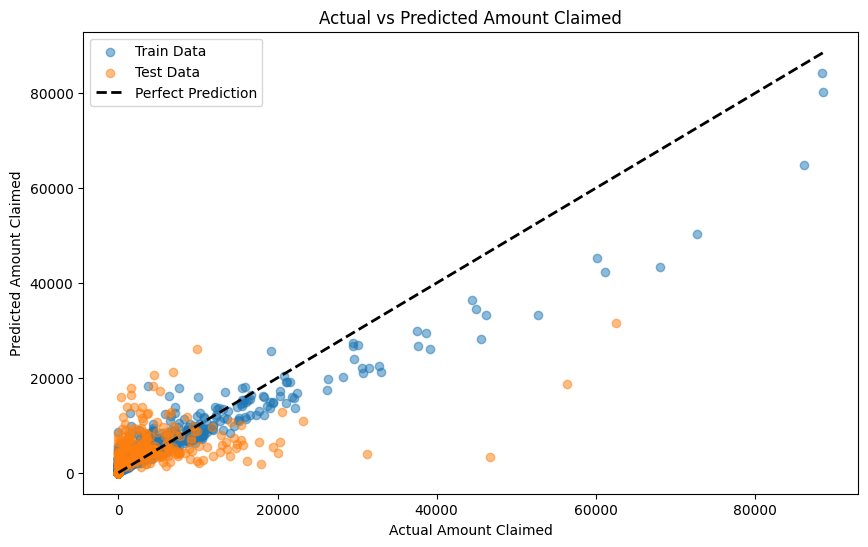

In [3]:
# plot y vs y_pred
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_train, alpha=0.5, label='Train Data')
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Test Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Amount Claimed')
plt.ylabel('Predicted Amount Claimed')
plt.title('Actual vs Predicted Amount Claimed')
plt.legend()
plt.show()

## 3. Two-Step Approach

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import classification_report, mean_squared_error, mean_absolute_error
from xgboost import XGBClassifier

# --- 1. Load your data ---
from policyML.bronze.bronze import get_db_connection
conn = get_db_connection()
query = 'SELECT * FROM silver.insurance;'
df = pd.read_sql(query, conn)
conn.close()

# --- 2. Prepare features and targets ---
df.drop(columns=["id", "dwh_create_data"], inplace=True)

# Target for regression
y = df["amt_claim"]
X = df.drop(columns=["amt_claim"])

# Binary target for claim occurrence
df["has_claim"] = (y > 0).astype(int)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
has_claim_train = (y_train > 0).astype(int)
has_claim_test = (y_test > 0).astype(int)

# --- 4. Classifier (Stage 1) ---
clf = RandomForestClassifier(n_jobs=-1, random_state=42)
clf.fit(X_train, has_claim_train)
# Alternatively, you can use XGBClassifier (same perforfmance as RandomForestClassifier)
#clf = XGBClassifier(scale_pos_weight=5, random_state=42)
#clf.fit(X_train, has_claim_train)

has_claim_pred = clf.predict(X_test)
has_claim_pred_proba = clf.predict_proba(X_test)[:, 1]

print("Classification report (claim/no claim):")
print(classification_report(has_claim_test, has_claim_pred))

# --- 5. Regressor (Stage 2) on non-zero claims ---
nonzero_mask = y_train > 0
X_train_reg = X_train[nonzero_mask]
y_train_reg = y_train[nonzero_mask]
#### Apply log transformation to stabilize variance (performance of model did not improve with log transformation so it was removed)
#y_train_reg_log = np.log1p(y_train_reg)

xgb_reg = XGBRegressor(n_jobs=-1, random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)

# Predict regression on all X_test (we'll zero it later)
y_reg_pred = xgb_reg.predict(X_test)

### Apply inverse log transformation
#y_reg_pred = np.expm1(y_reg_pred)

# --- 6. Combine predictions ---
# Only keep regression prediction where classifier predicts claim
final_pred = y_reg_pred * has_claim_pred

# --- 7. Evaluation ---
rmse = mean_squared_error(y_test, final_pred)
mae = mean_absolute_error(y_test, final_pred)

print(f"Final RMSE: {rmse:,.2f}")
print(f"Final MAE: {mae:,.2f}")



/var/folders/lx/thnwywfs79x9xsl2bq8yrjy00000gn/T/ipykernel_99545/164078602.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Classification report (claim/no claim):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4797
           1       0.94      1.00      0.97       203

    accuracy                           1.00      5000
   macro avg       0.97      1.00      0.98      5000
weighted avg       1.00      1.00      1.00      5000

Final RMSE: 2,204,757.86
Final MAE: 198.48


Classifier performs very well (f1 score high) and regressor performs slightly better than the previous model.

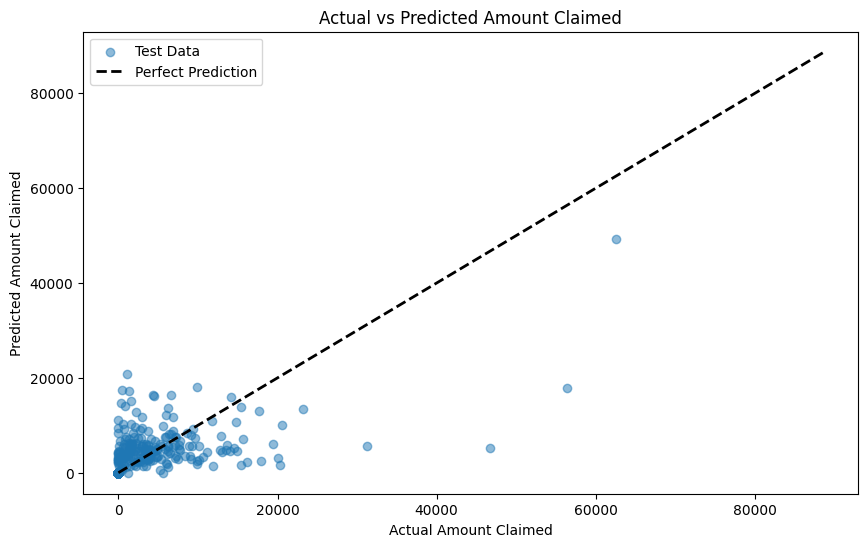

In [52]:
# plot y vs y_pred
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_pred, alpha=0.5, label='Test Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Amount Claimed')
plt.ylabel('Predicted Amount Claimed')
plt.title('Actual vs Predicted Amount Claimed')
plt.legend()
plt.show()

## 4. Tweedie with Optuna

In [ ]:
from lightgbm import LGBMRegressor, early_stopping


# Tweedie model
reg = LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.4,  # Between 1 and 2 for compound Poisson-Gamma
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

reg.fit(X_train, y_train)

y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

rmse_train = mean_squared_error(y_train, y_pred_train)
rmse_test = mean_squared_error(y_test, y_pred_test)

print(f"RMSE Train: {rmse_train:,.2f}")
print(f"RMSE Test: {rmse_test:,.2f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001887 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6991
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 44
[LightGBM] [Info] Start training from score 5.458694
RMSE Train: 1,316.49
RMSE Test: 2,490,671.97


In [ ]:
import optuna

# Optional: if you're using the full dataset
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        "objective": "tweedie",
        "tweedie_variance_power": trial.suggest_float("tweedie_variance_power", 1.1, 1.9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1
    }

    model = LGBMRegressor(**params)
    model.fit(X_subtrain, y_subtrain, eval_set=[(X_valid, y_valid)],
              callbacks=[
        early_stopping(stopping_rounds=50)],
    )

    preds = model.predict(X_valid)
    rmse = mean_squared_error(y_valid, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)  # You can increase this for better results

print("Best parameters:", study.best_params)
print("Best RMSE:", study.best_value)

In [42]:
print("Best parameters:", study.best_params)


Best parameters: {'tweedie_variance_power': 1.3081481802101986, 'learning_rate': 0.14005096947757895, 'n_estimators': 715, 'max_depth': 3, 'num_leaves': 110, 'subsample': 0.9455899245994004, 'colsample_bytree': 0.9652451418248094, 'min_child_samples': 100}


In [31]:
print(f"Best RMSE: {study.best_value:,.2f}")

Best RMSE: 2,507,732.11


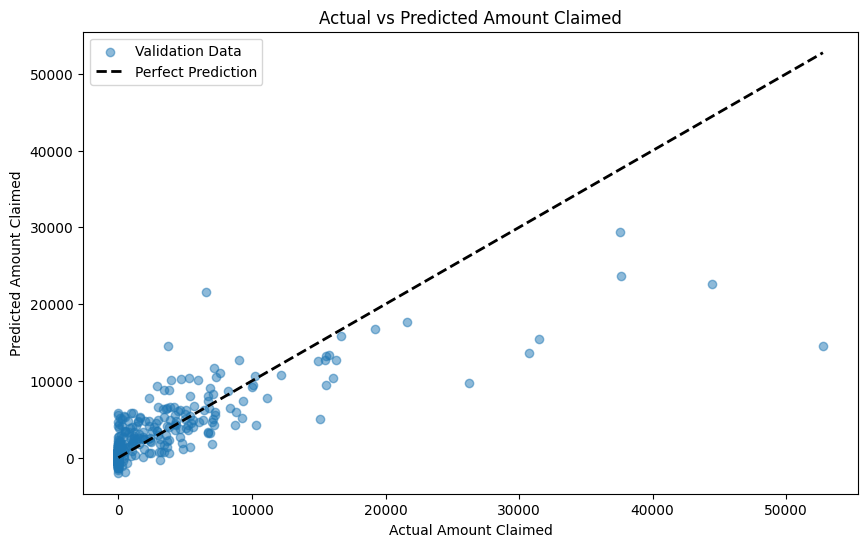

In [33]:
# get best parameters
best_params = study.best_params
# get predictions using best parameters
best_model = LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)
# plot y vs y_pred
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_valid, best_model.predict(X_valid), alpha=0.5, label='Validation Data')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Amount Claimed')
plt.ylabel('Predicted Amount Claimed')
plt.title('Actual vs Predicted Amount Claimed')
plt.legend()
plt.show()

##  Marginal plots of the best model

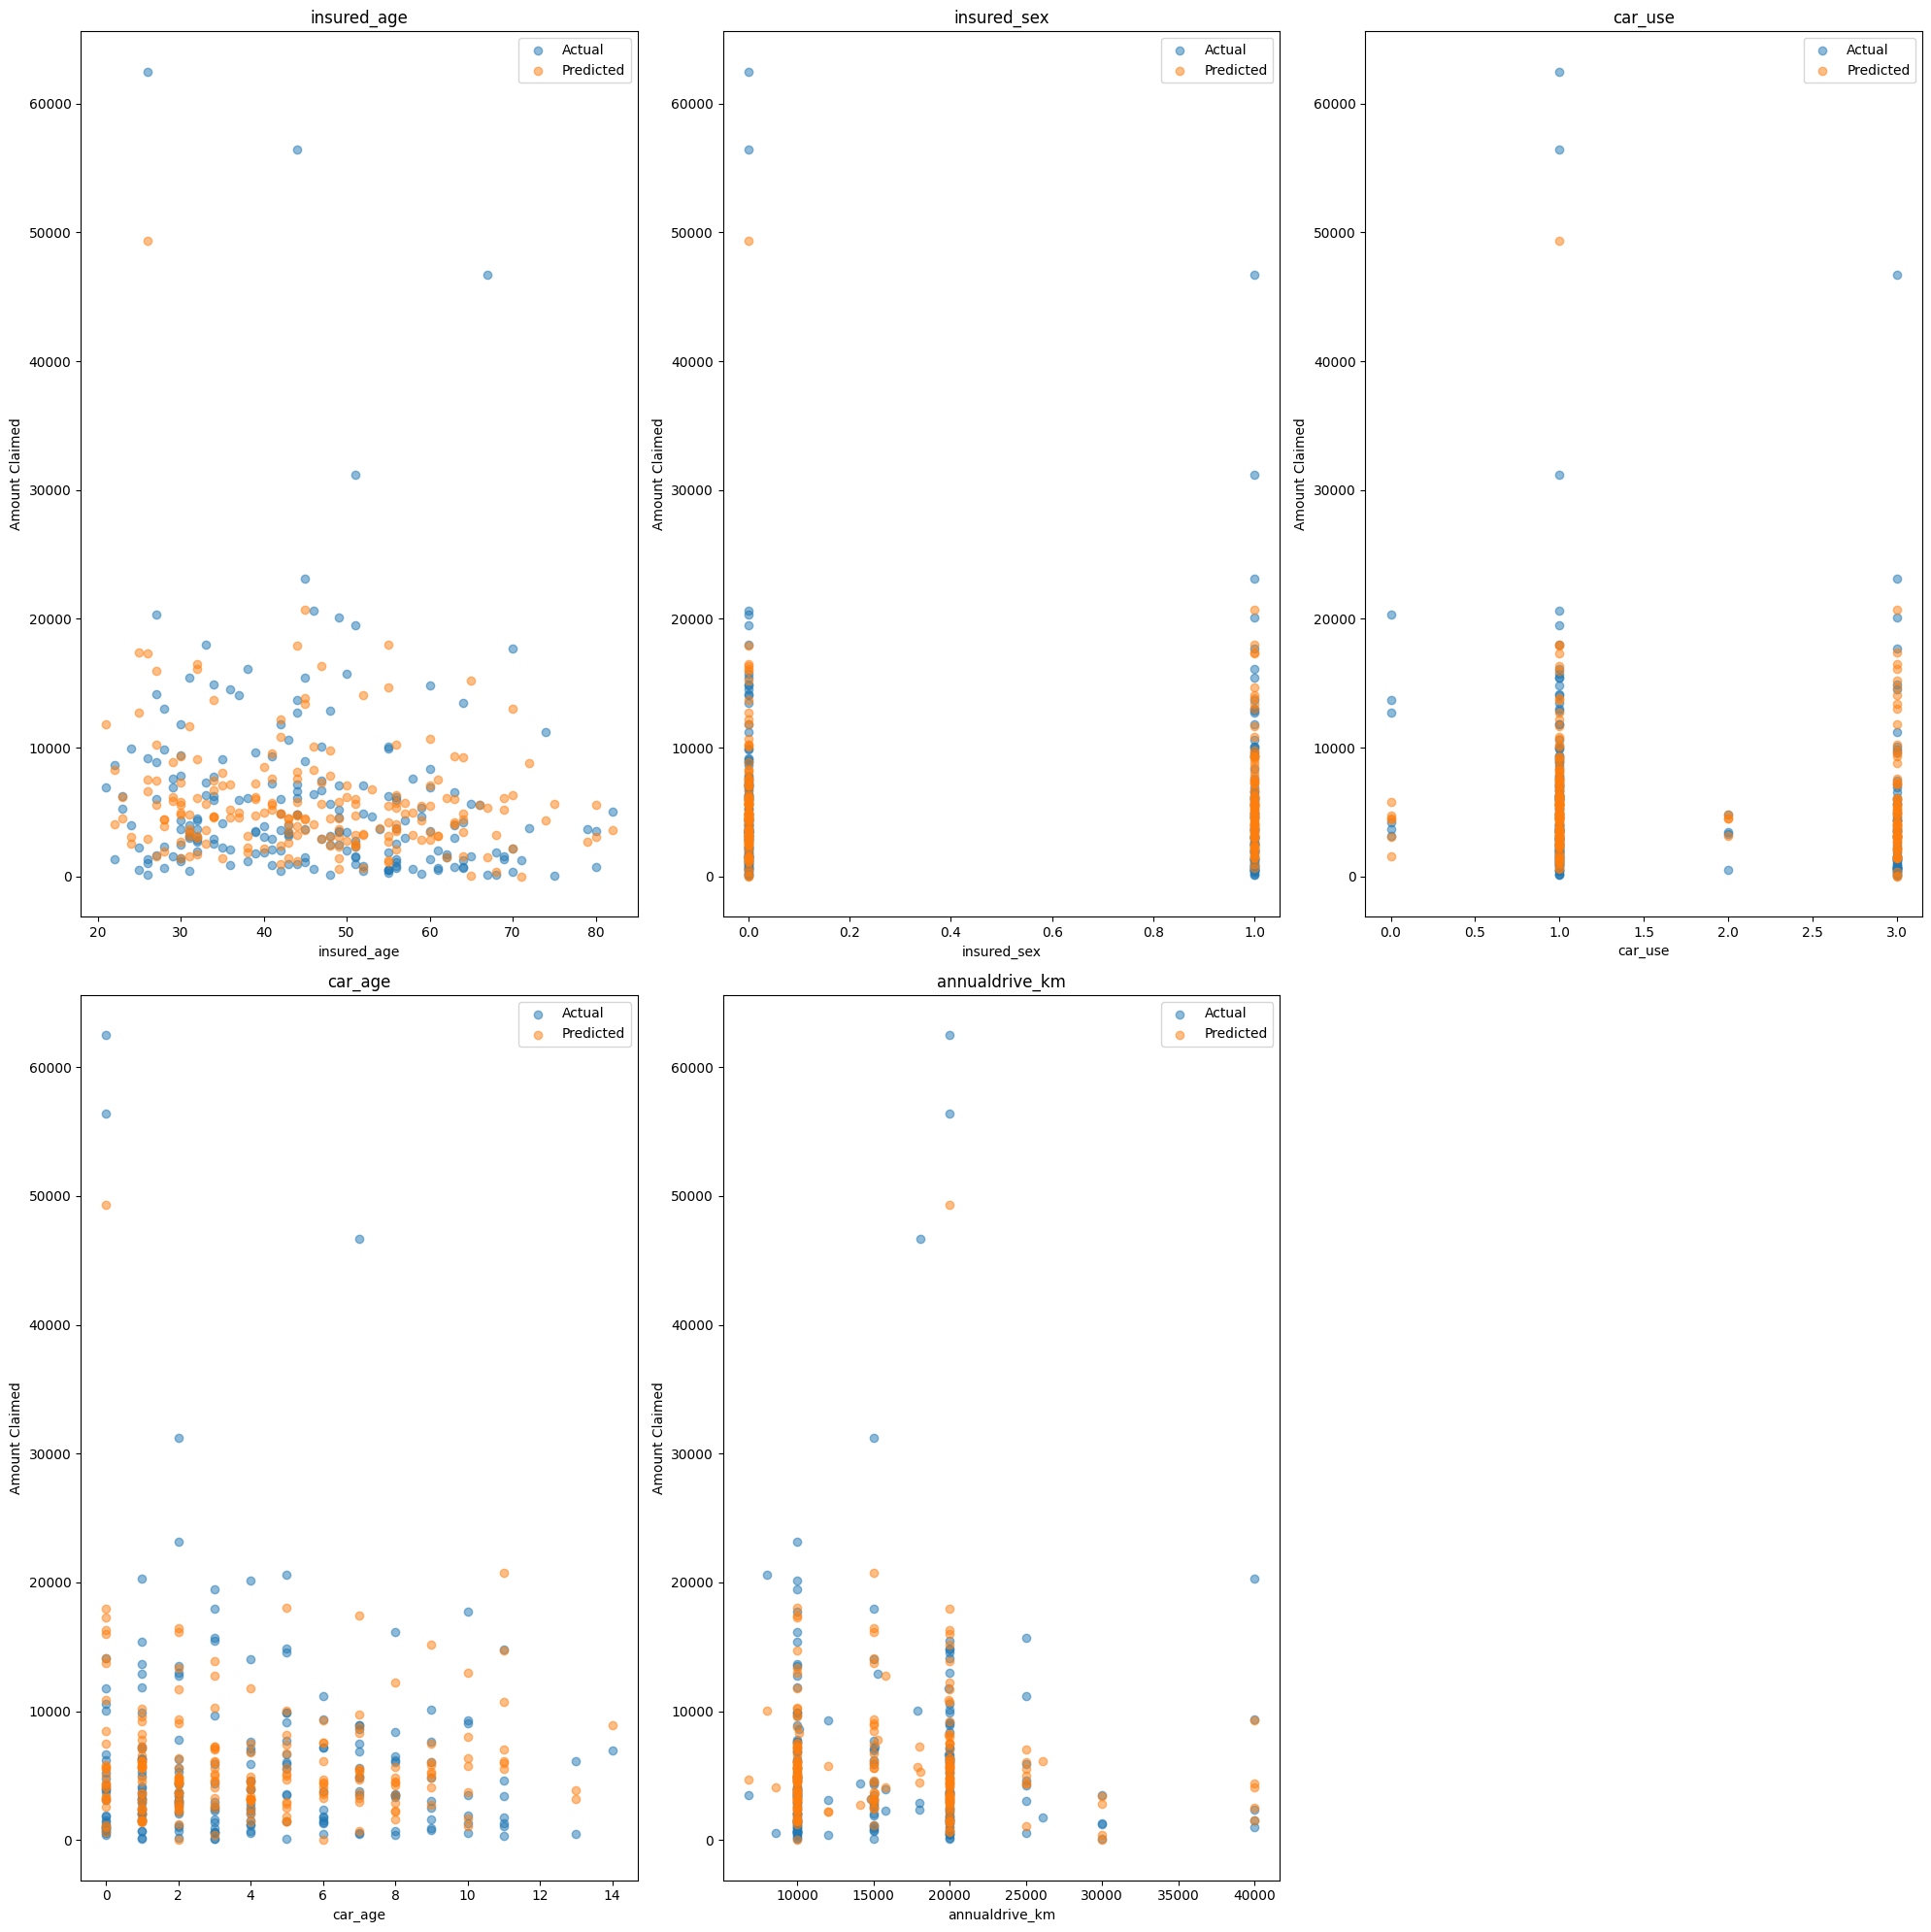

In [53]:
# plot most important feature (like insured_age, insured_sex, car_use, car_age, annualdrive_km) vs y and y_pred without zero values in y
X_test['amt_claim'] = y_test
X_test = X_test[X_test['amt_claim'] > 0]
y_test = y_test[y_test > 0]

has_claim_pred = clf.predict(X_test.drop(columns=['amt_claim']))
y_reg_pred = xgb_reg.predict(X_test.drop(columns=['amt_claim']))
# Combine predictions
final_pred = y_reg_pred * has_claim_pred

import matplotlib.pyplot as plt
plt.figure(figsize=(20, 20))
important_features = ['insured_age', 'insured_sex', 'car_use', 'car_age', 'annualdrive_km']
for feature in important_features:
    plt.subplot(2, 3, important_features.index(feature) + 1)
    plt.scatter(X_test[feature], y_test, alpha=0.5, label='Actual')
    plt.scatter(X_test[feature], final_pred, alpha=0.5, label='Predicted')
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('Amount Claimed')
    plt.legend()
plt.tight_layout()
plt.show()


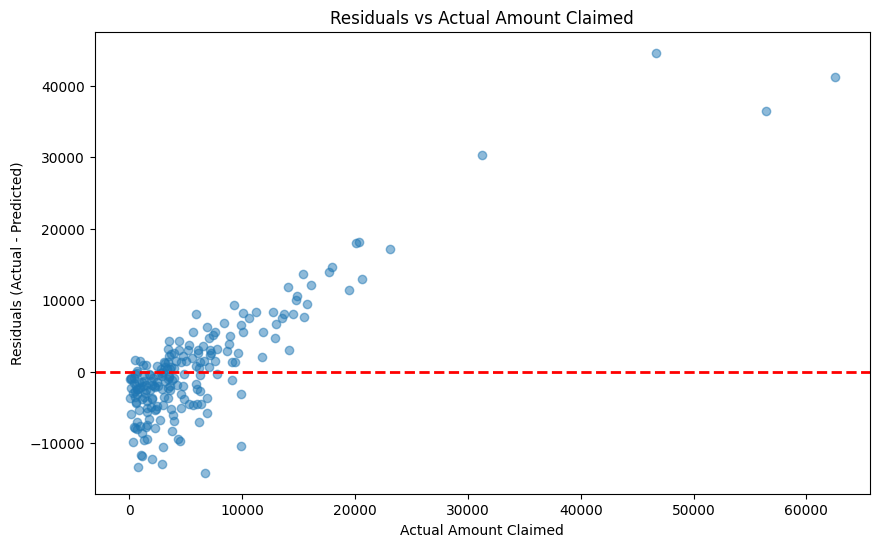

In [41]:
# plot the residuals (y - y_pred) vs y
residuals = y_test - best_model.predict(X_test.drop(columns=['amt_claim']))
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Actual Amount Claimed')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Actual Amount Claimed')
plt.show()


## Conclusion

1. Baseline Model - RMSE of 95M
2. Random Forest Regressor - RMSE of 2.5M
3. Two-Step Approach - RMSE of 2.2M
4. Tweedie with Optuna - RMSE of 2.5M

Two-step approach is the best model with RMSE of 2.2M, which is better of 0.3M compared to other approaches.

## Extra

In [12]:
# Save the predictions back to the dataframe
data["amt_claim"] = y_real

# select the rows with errors
error_data = data[data["amt_claim_error"] != 0]
error_data = error_data[["amt_claim", "amt_claim_pred", "amt_claim_error"]]


,amt_claim,amt_claim_pred,amt_claim_error
41,16.00,4186.2471,4170.2471
62,1524.51,8717.4893,7192.9793
77,6689.20,6440.2517,-248.9483
80,9856.58,12576.2732,2719.6932
152,3668.80,3800.1629,131.3629
...,...,...,...
24874,5354.12,5414.1661,60.0461
24911,30091.51,21429.4376,-8662.0724
24918,552.05,5289.4838,4737.4338
24952,669.49,10729.5323,10060.0423


<Axes: xlabel='amt_claim', ylabel='amt_claim_pred'>

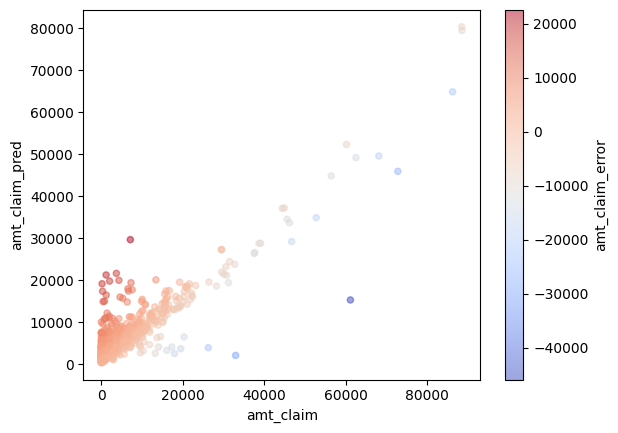

In [19]:
error_data.plot.scatter(x="amt_claim", y="amt_claim_pred", c="amt_claim_error", cmap="coolwarm", alpha=0.5)
